# 04b · Recognition-driven spotting (the decoder actually used on data_test)
The tagger above sees fluent real signing as one long *inside* run (no internal begin peaks), so the old decoder could only cut equal chunks. Spotting scores every 0.5–2.4 s window against the vocabulary and a semi-Markov DP picks non-overlapping words.

**Tuning/eval data:** synthetic sentences of held-out signer S_ttrs_00 with a bank that contains *no* clip of that signer (78% of that signer's words are therefore out-of-vocabulary, like real use). λ/γ/min_len tuned on split *tune*, reported on split *test*. data_test is never used for tuning.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

In [2]:
sp = read_json(REP/'v4_spotting.json')
display(pd.DataFrame(sp['results']).T[['seg_f1','boundary_f1','count_err','words_per_sentence_pred','words_per_sentence_gt','word_recall_top1','word_recall_top5','word_precision_top1','WER']].round(3))
print({k: v for k, v in sp['config'].items() if k != 'tiers_empirical'})

,seg_f1,boundary_f1,count_err,words_per_sentence_pred,words_per_sentence_gt,word_recall_top1,word_recall_top5,word_precision_top1,WER
tune|tagger_decoder,0.950,0.684,0.550,5.283,4.767,0.111,0.333,0.021,1.088
test|tagger_decoder,0.963,0.720,0.417,5.225,4.808,0.157,0.276,0.032,1.045
test|spotting+tagger_begin_prior,0.945,0.422,0.567,5.242,4.808,0.118,0.276,0.024,1.073
tune|spotting,0.909,0.222,0.683,5.183,4.767,0.093,0.296,0.016,1.104
test|spotting,0.928,0.191,0.583,5.075,4.808,0.118,0.236,0.025,1.057


{'lam': 9.0, 'gap_cost': 1.0, 'min_len': 14, 'lens': [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30], 'stride': 2, 'act_thr': 0.5, 'z_likely': 5.199740648269653, 'z_unknown': 4.187867116928101, 'tuned_on': 'synthetic sentences, held-out signer S_ttrs_00, bank without that signer'}


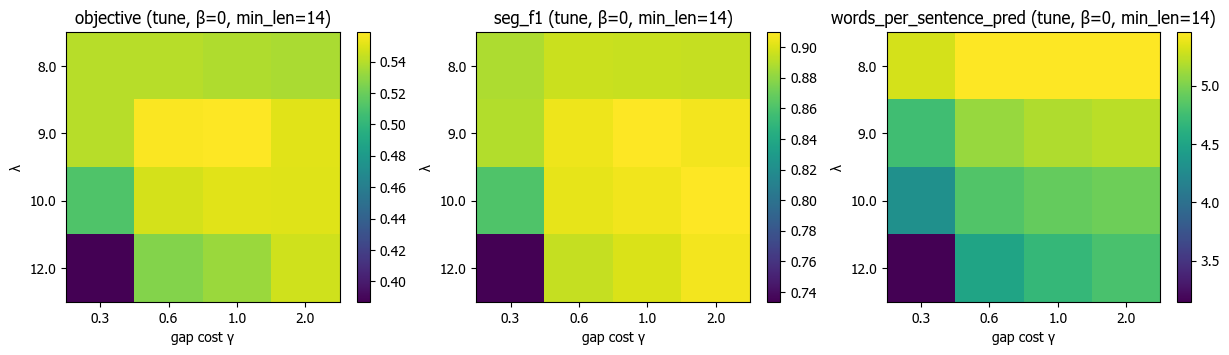

,beta,min_len,lam,gap_cost,seg_f1,boundary_f1,count_err,words_per_sentence_pred,word_recall_top5,objective
149,2.0,16,9.0,0.6,0.937,0.447,0.583,5.233,0.296,0.695
122,2.0,12,10.0,1.0,0.935,0.453,0.625,5.258,0.287,0.695
132,2.0,14,9.0,0.3,0.937,0.448,0.600,5.150,0.306,0.693
121,2.0,12,10.0,0.6,0.933,0.449,0.617,5.200,0.287,0.690
120,2.0,12,10.0,0.3,0.931,0.435,0.550,4.883,0.278,0.690
54,0.0,14,9.0,1.0,0.909,0.222,0.683,5.183,0.296,0.559
53,0.0,14,9.0,0.6,0.905,0.222,0.667,5.100,0.287,0.558
70,0.0,16,9.0,1.0,0.905,0.217,0.642,5.058,0.269,0.557
69,0.0,16,9.0,0.6,0.904,0.218,0.633,5.000,0.269,0.555
71,0.0,16,9.0,2.0,0.905,0.212,0.667,5.100,0.269,0.553


In [3]:
g = pd.DataFrame(sp['grid']); cfg = sp['config']
g0 = g[(g.beta == 0.0) & (g.min_len == cfg['min_len'])]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for a, col in zip(ax, ['objective', 'seg_f1', 'words_per_sentence_pred']):
    pv = g0.pivot(index='lam', columns='gap_cost', values=col); im = a.imshow(pv.values, aspect='auto', cmap='viridis')
    a.set_xticks(range(len(pv.columns))); a.set_xticklabels(pv.columns); a.set_yticks(range(len(pv.index))); a.set_yticklabels(pv.index)
    a.set_xlabel('gap cost γ'); a.set_ylabel('λ'); a.set_title(f"{col} (tune, β=0, min_len={cfg['min_len']})"); plt.colorbar(im, ax=a)
plt.show()
display(g.sort_values('objective', ascending=False).groupby('beta').head(5)[['beta','min_len','lam','gap_cost','seg_f1','boundary_f1','count_err','words_per_sentence_pred','word_recall_top5','objective']].round(3))

In [4]:
print(open(REP/'v4_spot_agg_check.txt', encoding='utf-8').read())

tune n in-vocab 108 {'single': (0.093, 0.296), 'vote': (0.093, 0.333), 'sum': (0.102, 0.352), 'max': (0.111, 0.296)}

test n in-vocab 127 {'single': (0.118, 0.236), 'vote': (0.142, 0.307), 'sum': (0.118, 0.299), 'max': (0.15, 0.299)}



